# IMPORTACIÓN DE LIBRERÍAS Y DEPENDENCIAS.
Este bloque inicial carga todas las herramientas necesarias para el proyecto, organizadas según su función: manipulación de datos, preprocesamiento, modelado, evaluación y persistencia.

In [47]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler

from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor

from pathlib import Path
import joblib

# CARGA Y EXPLORACIÓN INICIAL DEL CONJUNTO DE DATOS.
Establecemos la ruta base del proyecto, importamos los datos previamente limpios y realizamos una separación inicial entre las variables predictoras ($X$) y la variable objetivo ($y$). Posteriormente, inspeccionamos las dimensiones del dataset.

In [48]:
# Configuración de la ruta base y lectura del archivo CSV
BASE_DIR = Path().resolve().parent

df = pd.read_csv(BASE_DIR / "data" / "bike_clean.csv")

In [49]:
# Separación de características (X) y la variable objetivo (y)
X = df.drop(columns="cnt")
y = df["cnt"]

# Impresión de metadatos del conjunto de datos
print(f"Número de observaciones: {len(df)}")
print(f"Número de variables predictoras: {X.shape[1]}")
print(f"Variable objetivo: {y.name}")

# Visualización de las primeras filas
display(X.head())
display(y.head().to_frame())

Número de observaciones: 17377
Número de variables predictoras: 13
Variable objetivo: cnt


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,is_extreme_temp
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0


,cnt
0,16
1,40
2,32
3,13
4,1


# DIVISIÓN DEL DATASET Y DEFINICIÓN DE TIPOS DE VARIABLES.
Para garantizar una evaluación objetiva, dividimos los datos en conjuntos de entrenamiento (80%) y prueba (20%). Adicionalmente, clasificamos de forma explícita las columnas en categóricas y numéricas para su posterior procesamiento.

In [50]:
# División del dataset en entrenamiento (Train) y prueba (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [51]:
# Control de dimensiones resultantes
print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (13901, 13)
Test:  (3476, 13)


In [52]:
# Clasificación de características para el preprocesamiento
categorical_features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]
numeric_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

# CONFIGURACIÓN DEL PREPROCESAMIENTO Y MODELOS LINEALES.
Creamos un transformador de columnas (ColumnTransformer) para estandarizar las variables numéricas y aplicar codificación One-Hot a las categóricas. Luego, ensamblamos los pipelines para tres modelos basados en regresión lineal: Regresión Lineal Estándar, Ridge y Lasso.

In [53]:
# Configuración del preprocesador de datos
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [54]:
# Pipeline 1: Regresión Lineal Múltiple
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [55]:
# Pipeline 2: Regresión Ridge (Regularización L2)
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [56]:
# Pipeline 3: Regresión Lasso (Regularización L1)
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1))
])

# CONFIGURACIÓN DE MODELOS NO LINEALES Y AVANZADOS.
Definimos los pipelines para modelos basados en árboles de decisión y ensambles (Gradient Boosting), configurando hiperparámetros iniciales para mitigar el riesgo de sobreajuste.

In [57]:
# Pipeline 4: Árbol de Decisión Regresor
tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeRegressor(
            max_depth=10,
            min_samples_leaf=10,
            random_state=42
        )
    )
])

In [58]:
# Pipeline 5: XGBoost Regresor
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )
    )
])

# FUNCIÓN GENÉRICA DE EVALUACIÓN DE MODELOS.
Diseñamos una función automatizada que entrena el pipeline suministrado, realiza predicciones tanto en el set de entrenamiento como en el de validación, y calcula métricas clave de rendimiento (MSE, MAE, R²) junto con una estimación del Overfitting.

In [59]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    # Ajuste/Entrenamiento del modelo
    model.fit(X_train, y_train)
    
    # Predicciones de entrenamiento y prueba
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Cálculo de métricas de rendimiento en test
    mse = mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)

    # Análisis de sobreajuste (Diferencia de R² entre train y test)
    train_r2 = r2_score(y_train, y_train_pred)

    return {
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Overfitting": train_r2 - r2
    }

# EJECUCIÓN DEL ENTRENAMIENTO COMPARATIVO.
Agrupamos todos los pipelines en un diccionario y ejecutamos un ciclo iterativo para evaluar cada modelo de forma secuencial, almacenando los resultados obtenidos.

In [60]:
# Definición del diccionario de modelos a competir
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}
results = {}

# Iteración y evaluación masiva
for name, model in models.items():

    results[name] = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

# VISUALIZACIÓN Y ANÁLISIS DE RESULTADOS.
Convertimos el diccionario de resultados en un DataFrame de Pandas para su visualización tabular y generamos un gráfico de barras comparativo enfocado en el coeficiente de determinación ($R^2$).

In [61]:
# Transposición y construcción de la tabla de resultados
results_df = pd.DataFrame(results).T

results_df

,MSE,MAE,R2,Overfitting
Linear,10131.411487,74.421564,0.669988,0.019444
Ridge,10128.219966,74.410293,0.670092,0.019337
Lasso,10124.645803,74.312918,0.670209,0.018875
Decision Tree,8915.716152,69.570279,0.709587,0.039889
XGBoost,2171.010986,31.029181,0.929283,0.026855


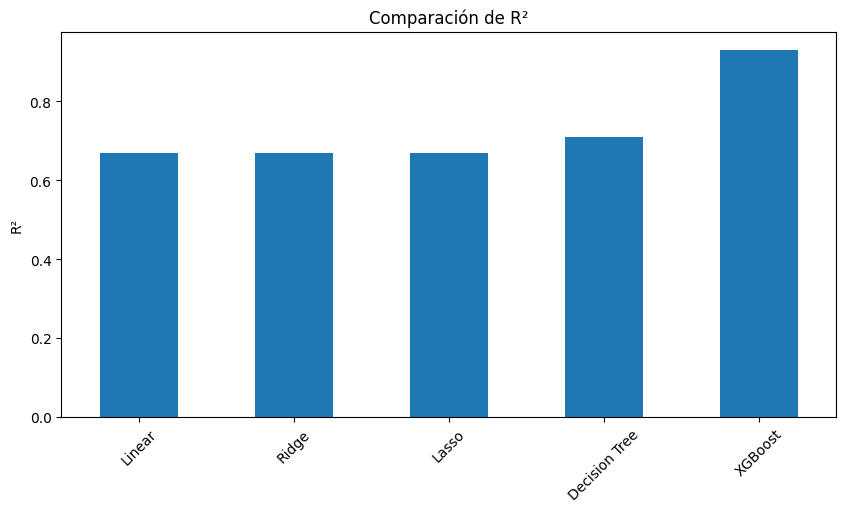

In [62]:
# Graficación del coeficiente R² por cada modelo
results_df["R2"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Comparación de R²")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.show()

# VALIDACIÓN CRUZADA ROBUSTA.
Configuramos una validación cruzada de 5 pliegues para evaluar el rendimiento de cada modelo utilizando la métrica $R^2$.

In [63]:
# Configuración del esquema K-Fold para una validación cruzada robusta
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [64]:
for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="r2"
    )

    print(
        f"{name}: "
        f"{scores.mean():.3f} "
        f"(±{scores.std():.3f})"
    )

Linear: 0.683 (±0.008)
Ridge: 0.683 (±0.008)
Lasso: 0.683 (±0.008)
Decision Tree: 0.710 (±0.010)
XGBoost: 0.929 (±0.003)


# EXTRACCIÓN Y AGRUPACIÓN DE LA IMPORTANCIA DE LAS VARIABLES.
En esta sección se extraen los coeficientes o importancias de cada modelo, se recuperan los nombres originales de las variables transformadas por el preprocessor y se agrupan aquellas que fueron divididas por el One-Hot Encoding (OHE).

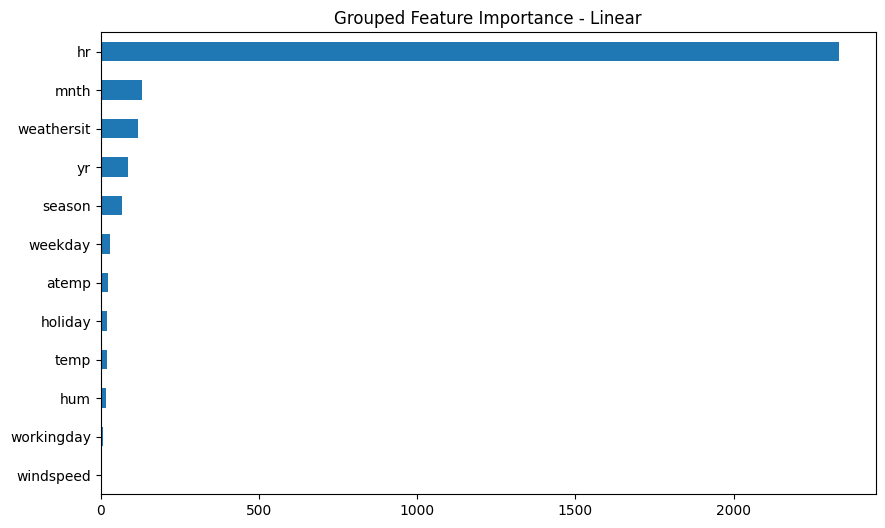

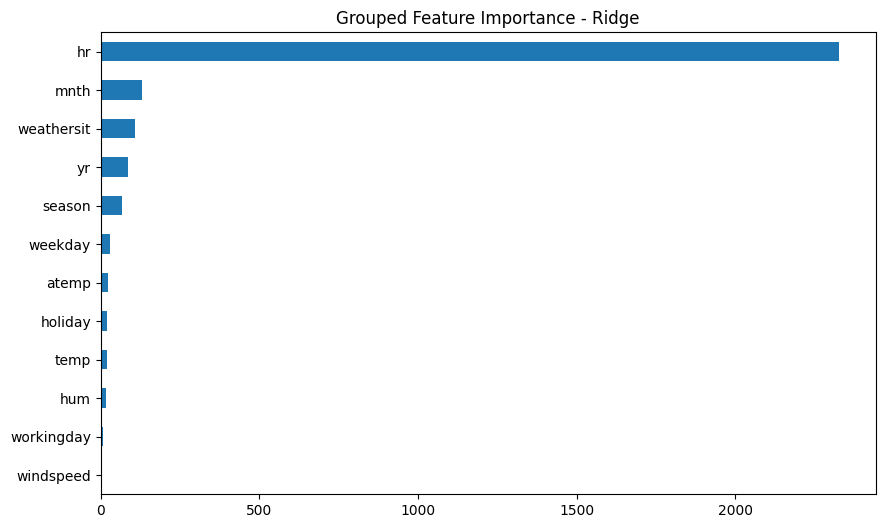

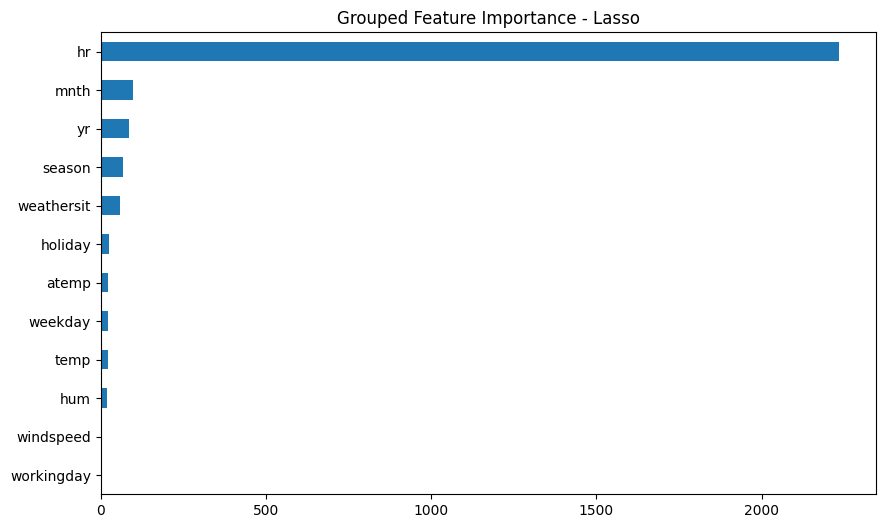

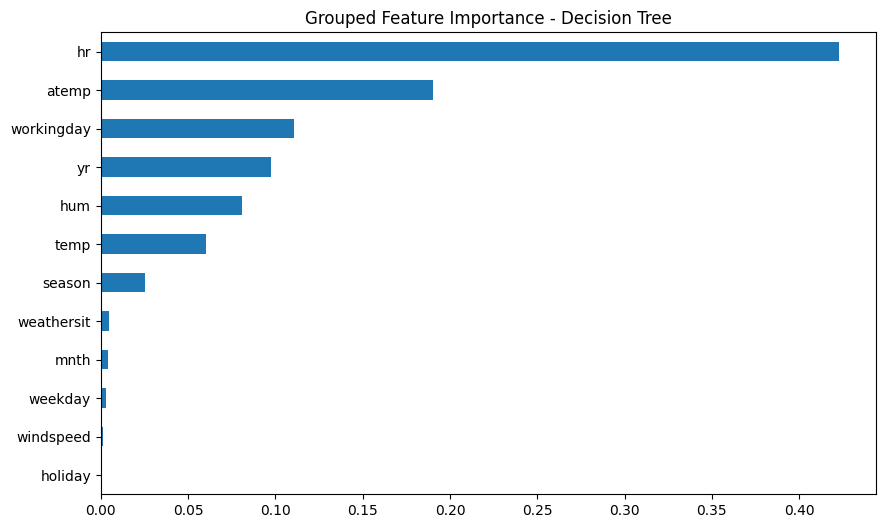

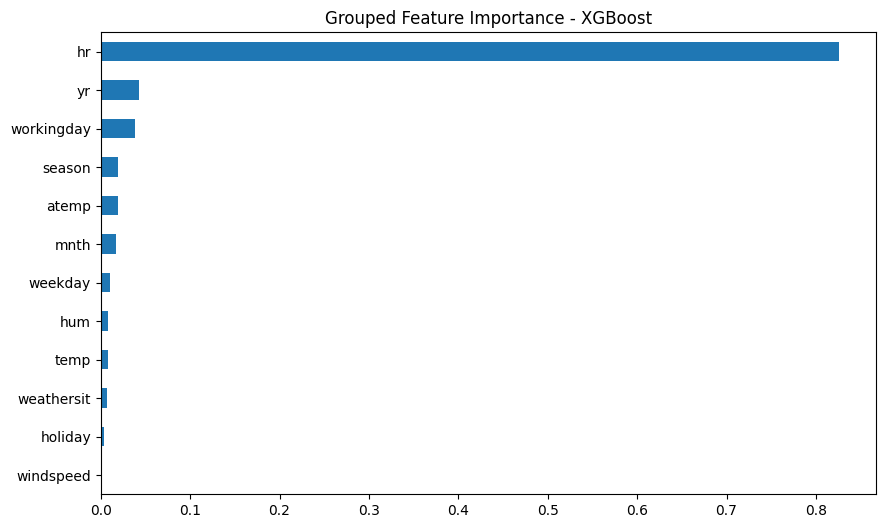

In [65]:
# Mapeo y nomenclatura de los pipelines creados
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}

all_importances = {}

for name, model in models.items():
    # Extraer el estimador final del pipeline
    estimator = model.named_steps["model"]

    # Obtención de la importancia/coeficientes según el tipo de modelo
    if hasattr(estimator, "coef_"):
        importance = np.abs(estimator.coef_)
    else:
        importance = estimator.feature_importances_

    # Recuperación de los nombres de las variables (features)
    ohe = model.named_steps["preprocessor"].named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(categorical_features)
    feature_names = list(numeric_features) + list(cat_names)
    
    # Crear Serie de pandas con las importancias mapeadas a sus nombres
    fi = pd.Series(importance, index=feature_names)

    # Agrupación de variables derivadas (ej. 'Color_Rojo' -> 'Color')
    grouped = {}

    for feature, value in fi.items():
        base = feature.split("_")[0]
        grouped[base] = grouped.get(base, 0) + value

    # Ordenar los valores calculados de menor a mayor
    grouped = pd.Series(grouped).sort_values(ascending=True)

    all_importances[name] = grouped

    # Generación de Gráficos 
    plt.figure(figsize=(10,6))
    # Se grafican únicamente las 15 variables más importantes
    grouped.tail(15).plot(kind="barh")
    plt.title(f"Grouped Feature Importance - {name}")
    plt.show()

# ANALISIS Y DIAGNÓSTICO DE RESIDUOS.
Este script genera las predicciones para cada modelo y evalúa la calidad del ajuste mediante el **análisis visual de los residuos** ($e = y_{test} - y_{pred}$). Para cada modelo se generan dos gráficos críticos: la distribución de los errores y el gráfico de dispersión de residuos frente a predicciones.


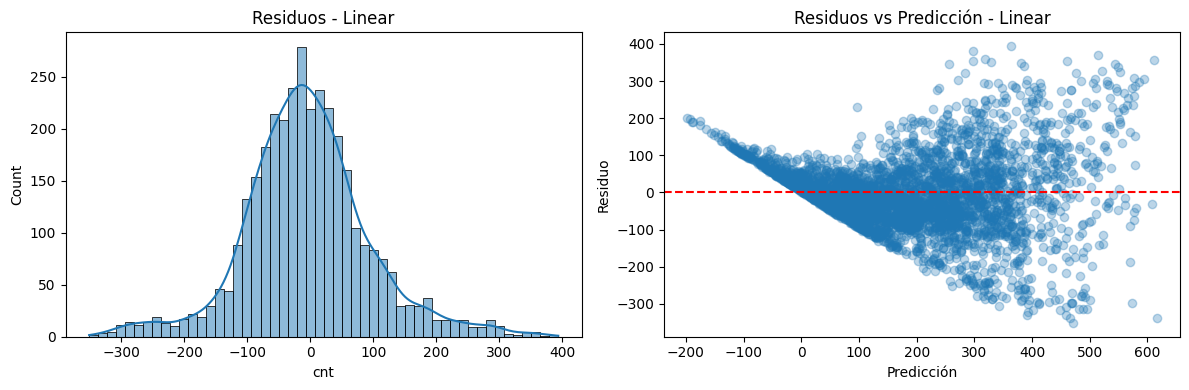

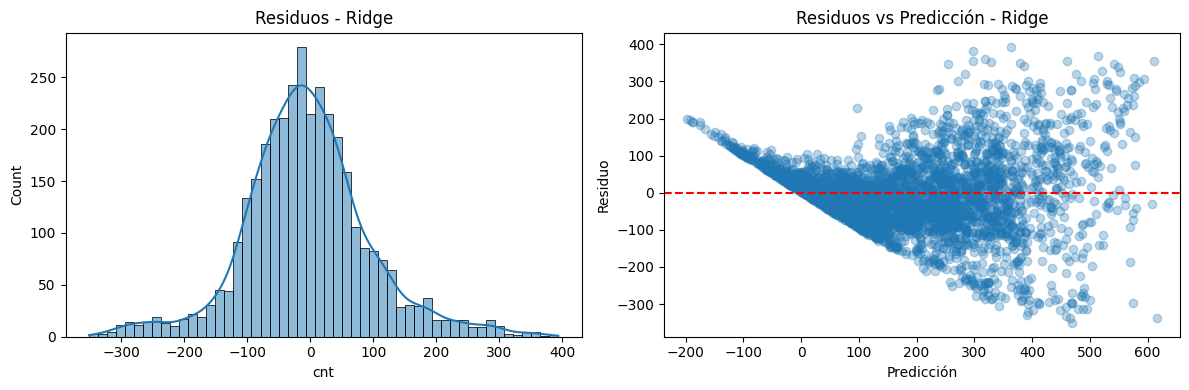

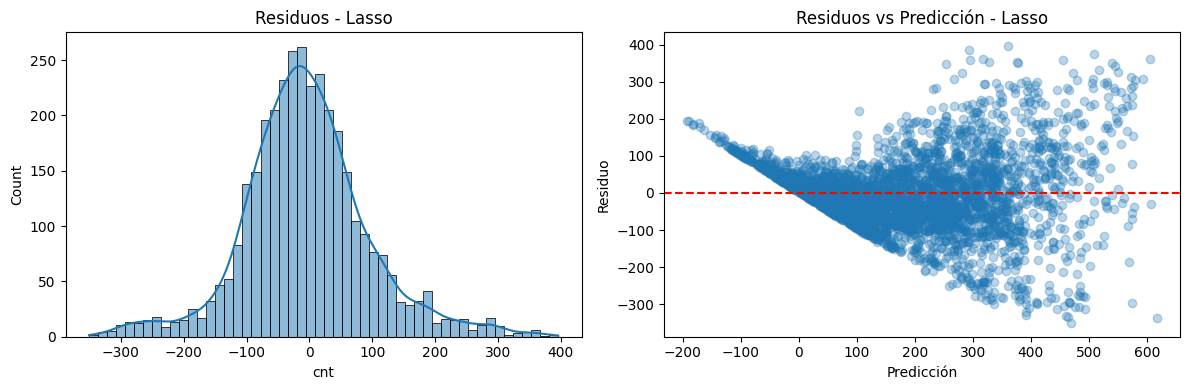

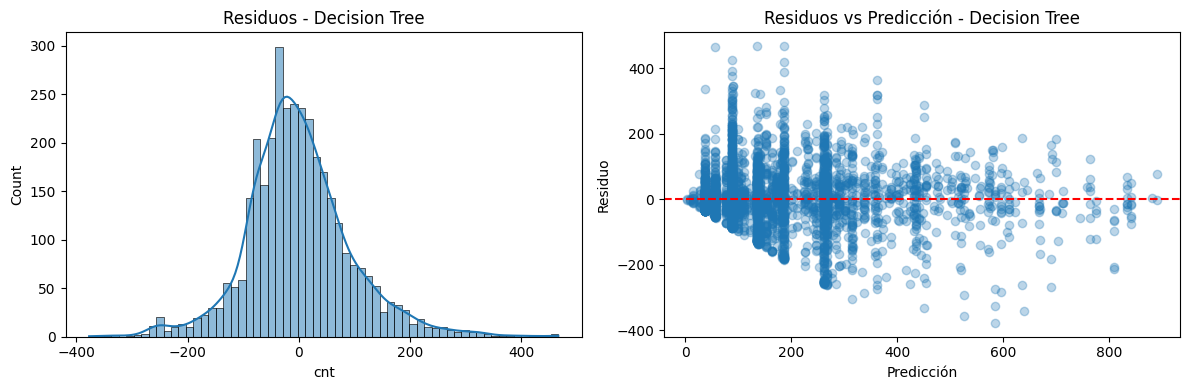

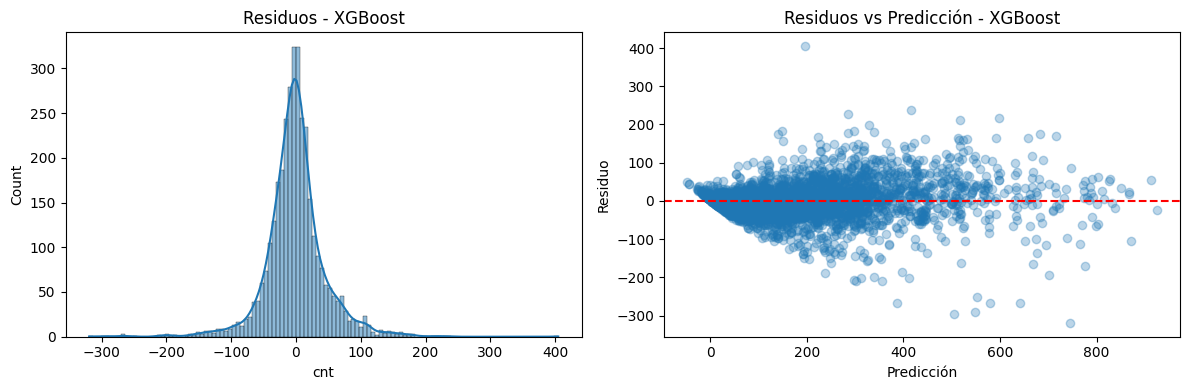

In [66]:
# Mapeo y nomenclatura de los pipelines evaluados
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}

# Diccionario para almacenar los residuos de cada modelo
residuals_dict = {}

for name, model in models.items():

    # Generar predicciones en el set de prueba
    y_pred = model.predict(X_test)

    # Calcular residuos (Valor Real - Valor Predicho)
    residuals = y_test - y_pred
    residuals_dict[name] = residuals

    # Inicializar el lienzo del gráfico (1 fila, 2 columnas)
    plt.figure(figsize=(12,4))

    # Distribución de los residuos. Permite evaluar si los errores siguen una distribución normal (media cero)
    plt.subplot(1,2,1)
    sns.histplot(residuals, kde=True)
    plt.title(f"Residuos - {name}")

    # Residuos vs predicción. Permite identificar problemas de homocedasticidad o patrones no lineales
    plt.subplot(1,2,2)
    plt.scatter(y_pred, residuals, alpha=0.3)
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"Residuos vs Predicción - {name}")
    plt.xlabel("Predicción")
    plt.ylabel("Residuo")
    
    # Ajustar elementos y mostrar gráficas del modelo actual
    plt.tight_layout()
    plt.show()

In [67]:
# Cálculo Rápido del Error Medio Absoluto (MAE)
for name, res in residuals_dict.items():
    print(name, np.mean(np.abs(res)))

Linear 74.42156416313793
Ridge 74.41029273839497
Lasso 74.31291844316587
Decision Tree 69.57027946151483
XGBoost 31.029180596168374


# GRÁFICOS DE DISPERSIÓN: VALORES REALES VS. PREDICCIONES.
Esta sección compara visualmente el valor real (y_test) frente al predicho (y_pred). La línea diagonal roja discontinua ($y = x$) representa el "modelo perfecto"; cuanto más cerca estén los puntos de esta línea, mejor es la predicción.

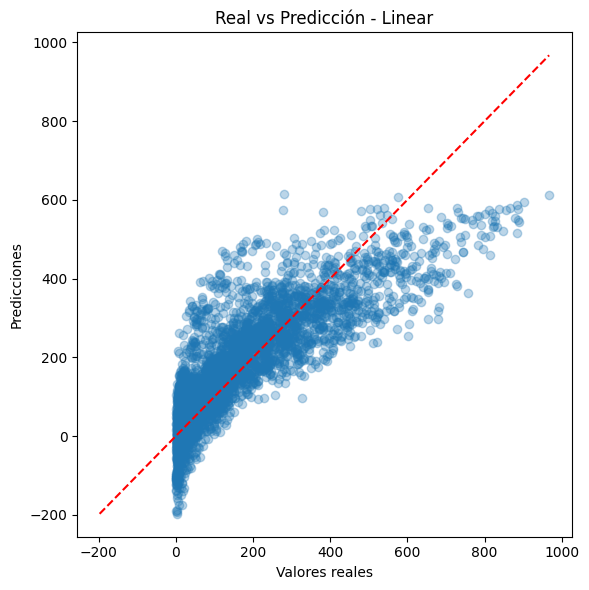

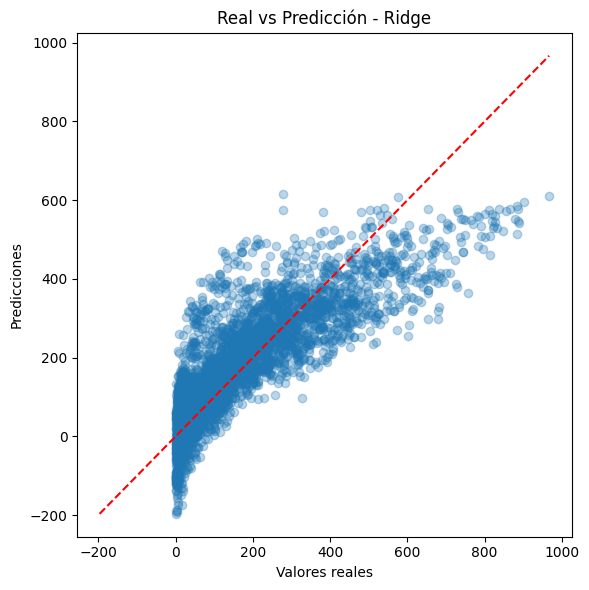

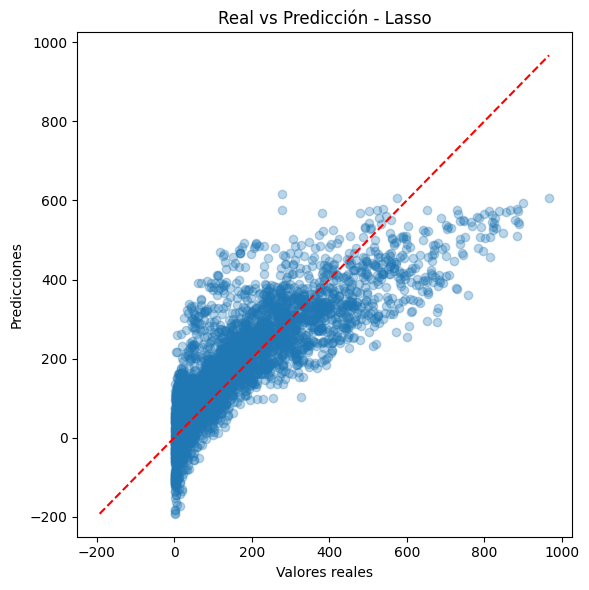

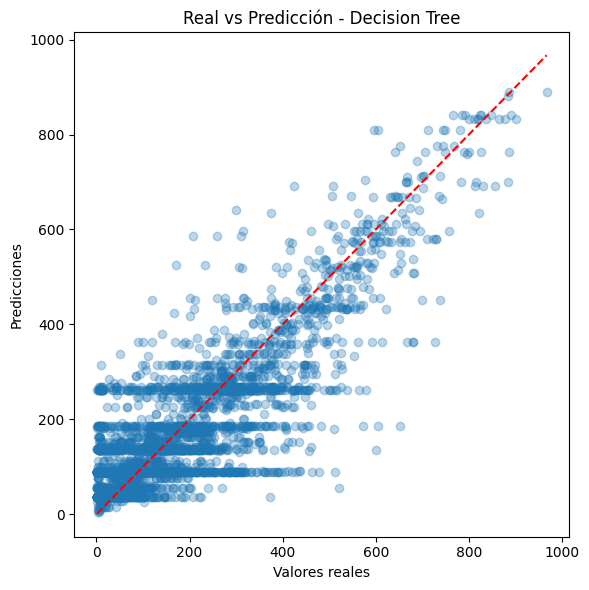

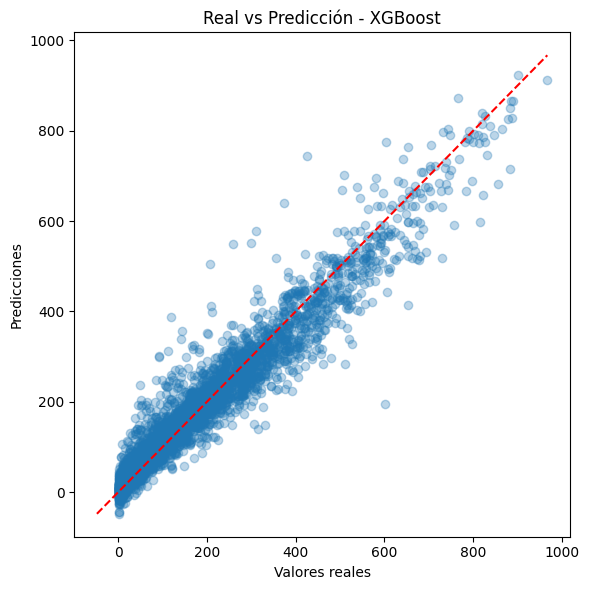

In [68]:
# Diccionario con los nombres y pipelines para la evaluación gráfica
models = {
    "Linear": linear_pipeline,
    "Ridge": ridge_pipeline,
    "Lasso": lasso_pipeline,
    "Decision Tree": tree_pipeline,
    "XGBoost": xgb_pipeline
}

for name, model in models.items():

    # Generar predicciones
    y_pred = model.predict(X_test)

    plt.figure(figsize=(6,6))

    plt.scatter(y_test, y_pred, alpha=0.3)

    # Definir los límites dinámicos para trazar una línea perfecta (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

    # Configuración de etiquetas y títulos
    plt.title(f"Real vs Predicción - {name}")
    plt.xlabel("Valores reales")
    plt.ylabel("Predicciones")

    plt.tight_layout()
    plt.show()

# PERSISTENCIA Y GUARDADO DE MODELOS (SERIALIZACIÓN).
Para finalizar, se crea una carpeta física llamada models (en caso de que no exista) y se guardan los pipelines utilizando la librería joblib con nombres en minúsculas (buenas prácticas para nombres de archivos).

In [69]:
# carpeta models
models_dir = BASE_DIR / "models"
models_dir.mkdir(exist_ok=True)
# Diccionario con nomenclatura adaptada para nombres de archivos (.pkl)
models = {
    "linear": linear_pipeline,
    "ridge": ridge_pipeline,
    "lasso": lasso_pipeline,
    "decision_tree": tree_pipeline,
    "xgboost": xgb_pipeline
}
# Bucle para serializar y exportar cada modelo
for name, model in models.items():
    path = models_dir / f"{name}_model.pkl"
    joblib.dump(model, path)
    print(f"Modelo guardado: {name} -> {path}")

Modelo guardado: linear -> C:\Users\pc\Desktop\BOOTCAMP DATA ANALYTIC\DA-Project-Regression-Grupo1\models\linear_model.pkl
Modelo guardado: ridge -> C:\Users\pc\Desktop\BOOTCAMP DATA ANALYTIC\DA-Project-Regression-Grupo1\models\ridge_model.pkl
Modelo guardado: lasso -> C:\Users\pc\Desktop\BOOTCAMP DATA ANALYTIC\DA-Project-Regression-Grupo1\models\lasso_model.pkl
Modelo guardado: decision_tree -> C:\Users\pc\Desktop\BOOTCAMP DATA ANALYTIC\DA-Project-Regression-Grupo1\models\decision_tree_model.pkl
Modelo guardado: xgboost -> C:\Users\pc\Desktop\BOOTCAMP DATA ANALYTIC\DA-Project-Regression-Grupo1\models\xgboost_model.pkl
